In [14]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [15]:
# Ajusta esto si tu notebook cambia de ubicación
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "global_crisis_data.csv"
DOCS_IMG_PATH = PROJECT_ROOT / "docs" / "img"
DOCS_DATA_PATH = PROJECT_ROOT / "docs" / "data"

DOCS_IMG_PATH.mkdir(parents=True, exist_ok=True)
DOCS_DATA_PATH.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)

PROJECT_ROOT: C:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS
DATA_PATH: C:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS\data\raw\global_crisis_data.csv


In [16]:
from src.limpieza import pipeline_limpieza_completa
from src.missing_data import (
    STUDY_VARS,
    filtrar_paises_exceso_missing,
    run_multiple_mice_by_country,
    resumen_imputacion,
    promediar_imputaciones,
)
from src.outliers import outliers_por_pais

In [17]:
study_vars = STUDY_VARS
study_vars

['inflation', 'gdp_growth', 'unemployment', 'fed_funds_rate']

In [20]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(3864, 15)


,iso3,year,crisis_next_12m,banking_crisis_next_12m,currency_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y
0,AGO,1960.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.21,NaN
1,AGO,1961.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,1.95,NaN
2,AGO,1962.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,2.71,NaN
3,AGO,1963.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.18,NaN
4,AGO,1964.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.50,NaN


In [21]:
df = pipeline_limpieza_completa(df)
print(df.shape)
df.head()

VALIDACIÓN PANEL:
nulos_iso3: 0
nulos_year: 0
duplicados_panel: 0
year_min: 1960
year_max: 2015
iso3_len_dist: {3: 3864}
(3864, 15)


,iso3,year,crisis_next_12m,banking_crisis_next_12m,currency_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y
0,AGO,1960,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.21,NaN
1,AGO,1961,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,1.95,NaN
2,AGO,1962,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,2.71,NaN
3,AGO,1963,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.18,NaN
4,AGO,1964,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.50,NaN


In [22]:
print("Columnas:")
print(df.columns.tolist())
print("\nTipos:")
print(df.dtypes)
print("\nAños:", df["year"].min(), "-", df["year"].max())
print("Países:", df["iso3"].nunique())
print("Observaciones:", len(df))

Columnas:
['iso3', 'year', 'crisis_next_12m', 'banking_crisis_next_12m', 'currency_crisis_next_12m', 'debt_crisis_next_12m', 'crisis_any', 'banking_crisis', 'currency_crisis', 'debt_crisis', 'inflation', 'gdp_growth', 'unemployment', 'fed_funds_rate', 'real_interest_rate_10y']

Tipos:
iso3                            str
year                          Int64
crisis_next_12m             float64
banking_crisis_next_12m     float64
currency_crisis_next_12m    float64
debt_crisis_next_12m        float64
crisis_any                    int64
banking_crisis                int64
currency_crisis               int64
debt_crisis                   int64
inflation                   float64
gdp_growth                  float64
unemployment                float64
fed_funds_rate              float64
real_interest_rate_10y      float64
dtype: object

Años: 1960 - 2015
Países: 69
Observaciones: 3864


In [23]:
df_filtered, countries_removed, miss_by_country = filtrar_paises_exceso_missing(
    df,
    study_vars=study_vars,
    country_col="iso3",
    threshold=0.50,
    min_vars=2,
)

print("Países removidos:", countries_removed)
print("N países original:", df["iso3"].nunique())
print("N países filtrado:", df_filtered["iso3"].nunique())
print("Observaciones originales:", len(df))
print("Observaciones filtradas:", len(df_filtered))

Países removidos: ['AGO', 'NIC', 'POL', 'PRK', 'ROU', 'RUS', 'TWN', 'ZWE']
N países original: 69
N países filtrado: 61
Observaciones originales: 3864
Observaciones filtradas: 3416


In [24]:
pd.DataFrame({"countries_removed": countries_removed})

,countries_removed
0,AGO
1,NIC
2,POL
3,PRK
4,ROU
5,RUS
6,TWN
7,ZWE


VER VALORES IMPUTADOS

In [25]:
missing_original_pct = (df[study_vars].isnull().mean() * 100).sort_values(ascending=False)
missing_filtered_pct = (df_filtered[study_vars].isnull().mean() * 100).sort_values(ascending=False)

missing_compare = pd.DataFrame({
    "missing_original_pct": missing_original_pct,
    "missing_filtered_pct": missing_filtered_pct,
})

missing_compare

,missing_original_pct,missing_filtered_pct
unemployment,46.247412,42.242389
inflation,14.932712,7.874707
gdp_growth,7.789855,2.166276
fed_funds_rate,0.000000,0.000000


In [ ]:
missing_por_pais = (
    df_filtered.groupby("iso3")[study_vars]
    .apply(lambda x: x.isnull().mean().mean() * 100)
    .sort_values(ascending=False)
)

missing_por_pais.head(15)


=== RESUMEN ESTADÍSTICO BASE ORIGINAL ===

         variable  mean_original  mean_imputed  std_original  std_imputed  \
0       inflation        26.5215       34.2243      280.3265     381.3394   
1      gdp_growth         3.8777        3.8335        4.4380       5.1974   
2    unemployment         7.3616        8.9391        4.6239       9.2610   
3  fed_funds_rate         5.2555        5.2555        3.5463       3.5463   

   min_imputed  max_imputed  diff_mean  diff_std      base  
0   -1978.6286   11749.6396     7.7028  101.0129  Original  
1     -36.3920      42.9869    -0.0442    0.7594  Original  
2       0.0000      68.1406     1.5775    4.6371  Original  
3       0.0900      16.3900     0.0000    0.0000  Original  

=== RESUMEN ESTADÍSTICO BASE FILTRADA ===

         variable  mean_original  mean_imputed  std_original  std_imputed  \
0       inflation        22.7300       24.6253      270.3282     323.2189   
1      gdp_growth         3.9436        3.9320        4.2549       

In [26]:
missing_por_year = (
    df_filtered.groupby("year")[study_vars]
    .apply(lambda x: x.isnull().mean().mean() * 100)
)

print("Primeros años:")
print(missing_por_year.head())
print("\nÚltimos años:")
print(missing_por_year.tail())

Primeros años:
year
1960    54.508197
1961    30.737705
1962    29.918033
1963    30.327869
1964    29.508197
dtype: float64

Últimos años:
year
2011    2.868852
2012    2.459016
2013    2.868852
2014    2.868852
2015    2.868852
dtype: float64


<Figure size 700x400 with 0 Axes>

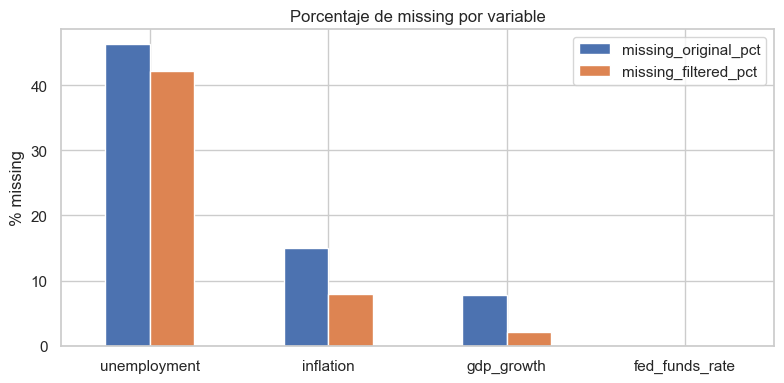

In [27]:
plt.figure(figsize=(7, 4))
missing_compare.plot(kind="bar", figsize=(8, 4))
plt.title("Porcentaje de missing por variable")
plt.ylabel("% missing")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
detalle_outliers_filt, resumen_outliers_filt = outliers_por_pais(
    df_filtered,
    study_vars=study_vars,
    country_col="iso3",
    time_col="year",
)

In [29]:
print("TOP outliers por país-variable")
resumen_outliers_filt.sort_values("pct_outliers", ascending=False).head(15)

TOP outliers por país-variable


,iso3,variable,n_outliers,n_obs,pct_outliers
112,MYS,unemployment,8,34,23.529412
24,IDN,inflation,10,56,17.857143
9,CHN,inflation,5,29,17.241379
4,BRA,inflation,6,35,17.142857
57,CHN,gdp_growth,9,55,16.363636
69,GHA,gdp_growth,9,55,16.363636
28,ITA,inflation,9,56,16.071429
3,BOL,inflation,9,56,16.071429
85,MUS,gdp_growth,8,55,14.545455
48,VEN,inflation,1,7,14.285714


In [30]:
detalle_outliers_filt.head(20)

,iso3,year,variable,valor,q1,q3,iqr,lower_bound,upper_bound
0,ARG,1981,fed_funds_rate,16.390000,3.140000,7.270000,4.130000,-3.055000,13.465000
1,AUS,1981,fed_funds_rate,16.390000,3.140000,7.270000,4.130000,-3.055000,13.465000
2,AUS,1964,gdp_growth,6.977572,2.572295,4.079081,1.506786,0.312116,6.339260
3,AUS,1969,gdp_growth,7.047602,2.572295,4.079081,1.506786,0.312116,6.339260
4,AUS,1970,gdp_growth,7.174700,2.572295,4.079081,1.506786,0.312116,6.339260
5,AUS,1983,gdp_growth,-2.225824,2.572295,4.079081,1.506786,0.312116,6.339260
6,AUS,1991,gdp_growth,-0.384631,2.572295,4.079081,1.506786,0.312116,6.339260
7,AUS,1974,inflation,15.416667,2.423230,7.383242,4.960012,-5.016787,14.823260
8,AUS,1975,inflation,15.162455,2.423230,7.383242,4.960012,-5.016787,14.823260
9,AUT,1981,fed_funds_rate,16.390000,3.140000,7.270000,4.130000,-3.055000,13.465000


In [ ]:
#CORRELACIONES ANTES DE IMPUTAR
corr_before = df_filtered[study_vars].corr(numeric_only=True)
corr_before

,inflation,gdp_growth,unemployment,fed_funds_rate
inflation,1.000000,-0.079719,0.053194,0.045645
gdp_growth,-0.079719,1.000000,-0.220118,0.001601
unemployment,0.053194,-0.220118,1.000000,-0.085435
fed_funds_rate,0.045645,0.001601,-0.085435,1.000000


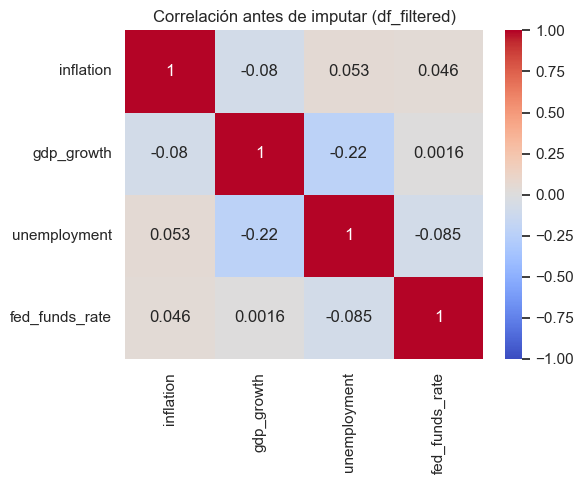

In [32]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_before, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación antes de imputar (df_filtered)")
plt.tight_layout()
plt.show()

In [33]:
df_imputed_country_list = run_multiple_mice_by_country(
    df_filtered,
    study_vars=study_vars,
    country_col="iso3",
    time_col="year",
    n_imputations=5,
    max_iter=20,
    random_state=0,
)

len(df_imputed_country_list)

5

In [34]:
df_imp_diag = df_imputed_country_list[0]
df_imp_diag.head()

,iso3,year,crisis_next_12m,banking_crisis_next_12m,currency_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y,imputation_id
0,ARG,1960,1.0,0.0,0.0,1.0,1,0,0,1,NaN,16.161537,40.000000,3.21,NaN,1
1,ARG,1961,1.0,0.0,0.0,1.0,1,0,0,1,NaN,5.427843,0.000000,1.95,NaN,1
2,ARG,1962,1.0,0.0,0.0,1.0,1,0,0,1,NaN,-0.852022,0.000000,2.71,NaN,1
3,ARG,1963,1.0,0.0,0.0,1.0,1,0,0,1,NaN,-5.308197,8.425911,3.18,NaN,1
4,ARG,1964,1.0,0.0,0.0,1.0,1,0,0,1,NaN,10.130298,0.000000,3.50,NaN,1


In [35]:
df_final = promediar_imputaciones(df_imputed_country_list)
print(df_final.shape)
df_final.head()

(3416, 15)


,iso3,year,crisis_next_12m,banking_crisis_next_12m,currency_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y
0,ARG,1960,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,10.505095,24.000000,3.21,NaN
1,ARG,1961,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,5.427843,21.328682,1.95,NaN
2,ARG,1962,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,-0.852022,15.429053,2.71,NaN
3,ARG,1963,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,-5.308197,9.685182,3.18,NaN
4,ARG,1964,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,10.130298,8.000000,3.50,NaN


In [36]:
df_final["year"] = df_final["year"].astype("Int64")
print(df_final.dtypes)

iso3                            str
year                          Int64
crisis_next_12m             float64
banking_crisis_next_12m     float64
currency_crisis_next_12m    float64
debt_crisis_next_12m        float64
crisis_any                  float64
banking_crisis              float64
currency_crisis             float64
debt_crisis                 float64
inflation                   float64
gdp_growth                  float64
unemployment                float64
fed_funds_rate              float64
real_interest_rate_10y      float64
dtype: object


In [37]:
summary_final = resumen_imputacion(
    df_filtered,
    df_final,
    study_vars=study_vars,
    base_name="filtered_pooling"
)

summary_final

,variable,mean_original,mean_imputed,std_original,std_imputed,min_imputed,max_imputed,diff_mean,diff_std,base
0,inflation,22.729979,19.263202,270.328243,55.592371,-100.000000,500.000000,-3.466777,-214.735872,filtered_pooling
1,gdp_growth,3.943597,3.990108,4.254852,4.587172,-45.844777,42.410414,0.046512,0.332319,filtered_pooling
2,unemployment,7.289360,10.534441,4.641036,7.643787,0.000000,40.000000,3.245080,3.002752,filtered_pooling
3,fed_funds_rate,5.255536,5.255536,3.546331,3.546331,0.090000,16.390000,0.000000,0.000000,filtered_pooling


In [38]:
missing_residual_pct = (df_final[study_vars].isnull().mean() * 100).sort_values(ascending=False)

print("MISSING RESIDUAL EN DF_FINAL (%)")
print(missing_residual_pct)

MISSING RESIDUAL EN DF_FINAL (%)
inflation         1.639344
unemployment      1.639344
gdp_growth        0.000000
fed_funds_rate    0.000000
dtype: float64


In [39]:
corr_after = df_final[study_vars].corr(numeric_only=True)
corr_after

,inflation,gdp_growth,unemployment,fed_funds_rate
inflation,1.000000,-0.088733,0.091850,0.132048
gdp_growth,-0.088733,1.000000,-0.019946,-0.005338
unemployment,0.091850,-0.019946,1.000000,0.066829
fed_funds_rate,0.132048,-0.005338,0.066829,1.000000


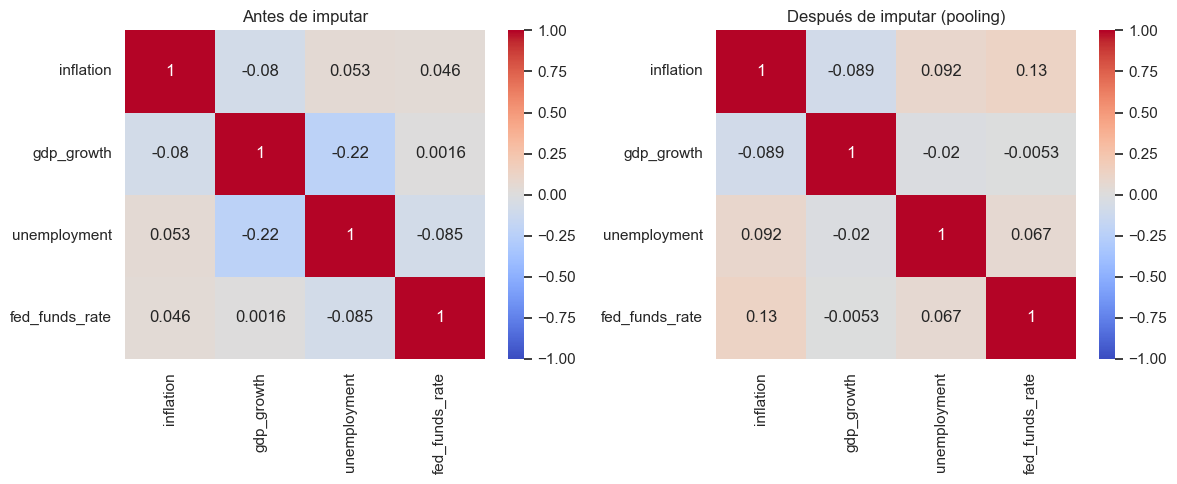

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(corr_before, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Antes de imputar")

sns.heatmap(corr_after, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Después de imputar (pooling)")

plt.tight_layout()
plt.show()

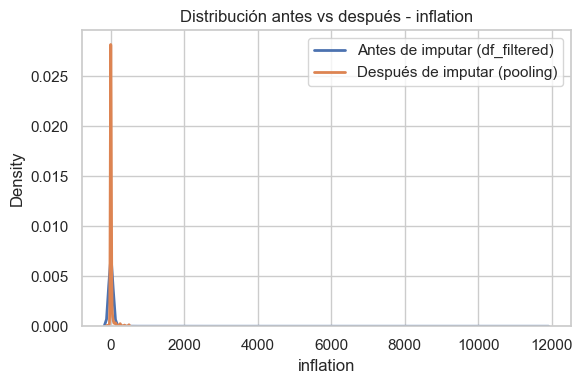

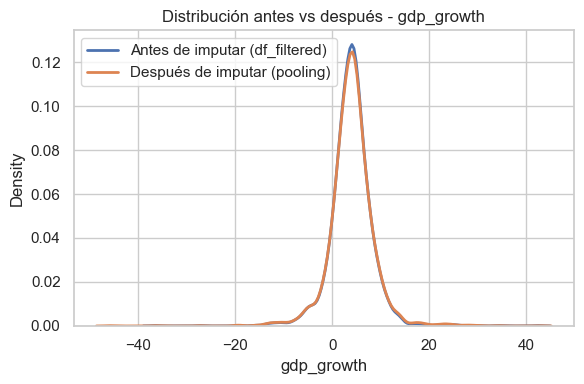

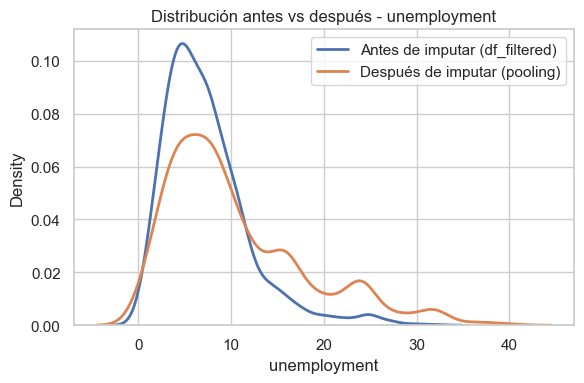

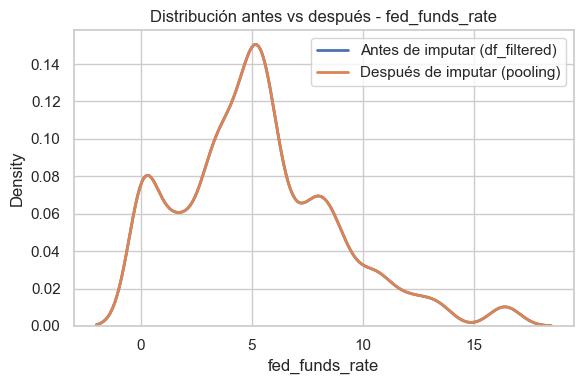

In [41]:
for var in study_vars:
    plt.figure(figsize=(6, 4))

    sns.kdeplot(
        df_filtered[var].dropna(),
        label="Antes de imputar (df_filtered)",
        linewidth=2
    )

    sns.kdeplot(
        df_final[var].dropna(),
        label="Después de imputar (pooling)",
        linewidth=2
    )

    plt.title(f"Distribución antes vs después - {var}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [42]:
for var in study_vars:
    plt.figure(figsize=(6, 4))

    sns.kdeplot(
        df_filtered[var].dropna(),
        label="Antes de imputar",
        linewidth=2
    )

    sns.kdeplot(
        df_final[var].dropna(),
        label="Después de imputar (pooling)",
        linewidth=2
    )

    plt.title(f"Distribución antes vs después - {var}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(DOCS_IMG_PATH / f"distribution_mice_{var}.png", dpi=300, bbox_inches="tight")
    plt.close()

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(corr_before, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Antes de imputar")

sns.heatmap(corr_after, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Después de imputar (pooling)")

plt.tight_layout()
plt.savefig(DOCS_IMG_PATH / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

#**METRICAS PARA LA PAGINA**

In [44]:
eda_stats = {
    "n_obs_original": int(len(df)),
    "n_obs_filtered": int(len(df_filtered)),
    "year_min": int(df_filtered["year"].min()),
    "year_max": int(df_filtered["year"].max()),
    "n_years": int(df_filtered["year"].max() - df_filtered["year"].min() + 1),
    "n_countries_original": int(df["iso3"].nunique()),
    "n_countries_filtered": int(df_filtered["iso3"].nunique()),
    "countries_removed_count": int(len(countries_removed)),
    "countries_removed": countries_removed,
    "study_vars": study_vars,
    "missing_original_pct": missing_original_pct.round(4).to_dict(),
    "missing_filtered_pct": missing_filtered_pct.round(4).to_dict(),
    "missing_residual_pct": missing_residual_pct.round(4).to_dict(),
    "summary_final": summary_final.round(4).to_dict(orient="records"),
}
eda_stats

{'n_obs_original': 3864,
 'n_obs_filtered': 3416,
 'year_min': 1960,
 'year_max': 2015,
 'n_years': 56,
 'n_countries_original': 69,
 'n_countries_filtered': 61,
 'countries_removed_count': 8,
 'countries_removed': ['AGO', 'NIC', 'POL', 'PRK', 'ROU', 'RUS', 'TWN', 'ZWE'],
 'study_vars': ['inflation', 'gdp_growth', 'unemployment', 'fed_funds_rate'],
 'missing_original_pct': {'unemployment': 46.2474,
  'inflation': 14.9327,
  'gdp_growth': 7.7899,
  'fed_funds_rate': 0.0},
 'missing_filtered_pct': {'unemployment': 42.2424,
  'inflation': 7.8747,
  'gdp_growth': 2.1663,
  'fed_funds_rate': 0.0},
 'missing_residual_pct': {'inflation': 1.6393,
  'unemployment': 1.6393,
  'gdp_growth': 0.0,
  'fed_funds_rate': 0.0},
 'summary_final': [{'variable': 'inflation',
   'mean_original': 22.73,
   'mean_imputed': 19.2632,
   'std_original': 270.3282,
   'std_imputed': 55.5924,
   'min_imputed': -100.0,
   'max_imputed': 500.0,
   'diff_mean': -3.4668,
   'diff_std': -214.7359,
   'base': 'filtered_p

In [45]:
import json

with open(DOCS_DATA_PATH / "eda_stats.json", "w", encoding="utf-8") as f:
    json.dump(eda_stats, f, ensure_ascii=False, indent=2)

print("Guardado:", DOCS_DATA_PATH / "eda_stats.json")

Guardado: C:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS\docs\data\eda_stats.json


In [46]:
OUTPUT_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_PROCESSED.mkdir(parents=True, exist_ok=True)

df_final.to_csv(OUTPUT_PROCESSED / "global_crisis_data_imputed_filtered.csv", index=False)
print("Guardado:", OUTPUT_PROCESSED / "global_crisis_data_imputed_filtered.csv")

Guardado: C:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS\data\processed\global_crisis_data_imputed_filtered.csv


In [47]:
print("df_filtered:", df_filtered.shape)
print("df_final:", df_final.shape)
print("Imágenes guardadas en:", DOCS_IMG_PATH)
print("JSON guardado en:", DOCS_DATA_PATH / "eda_stats.json")

df_filtered: (3416, 15)
df_final: (3416, 15)
Imágenes guardadas en: C:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS\docs\img
JSON guardado en: C:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS\docs\data\eda_stats.json
